In [1]:
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

# import multiprocessing 
# # tried moving Optuna + CatBoost to gpu here, but failed to get it fast enough, 
# most certanly due to some memory transfer issue :(
# typical python staff, btw

# from tqdm import tqdm

from numpy import ndarray
from pandas import DataFrame, Series
from typing import Optional, Any
from scipy.linalg import LinAlgWarning

from catboost import CatBoostRegressor, CatBoostClassifier #, Pool, cv # same try on GPU

from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
    f1_score,
    classification_report,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
)

from optuna.integration import CatBoostPruningCallback

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category = LinAlgWarning)

# EDA

Shape: (1001, 213)
Duplicates: 32
Missing values: 36


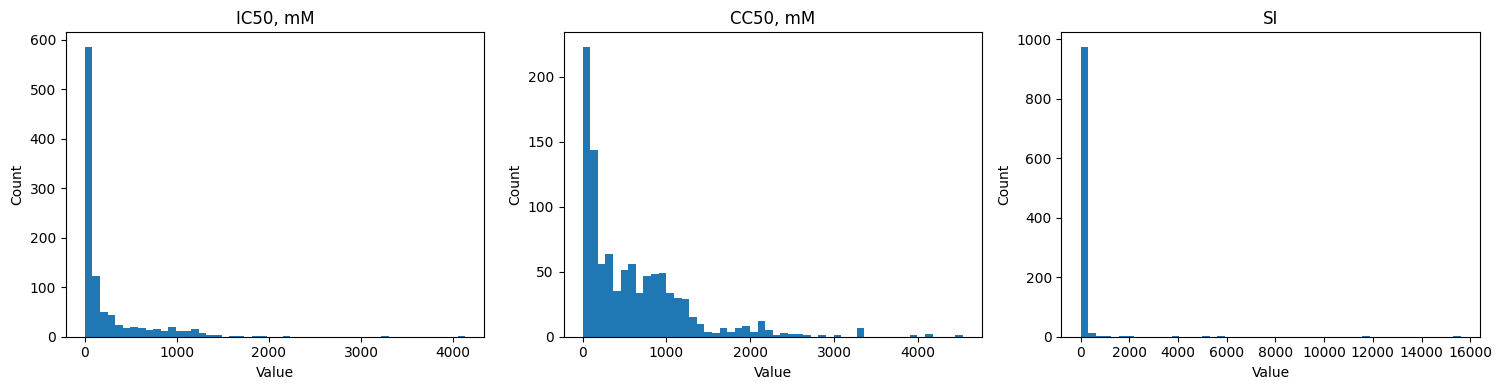

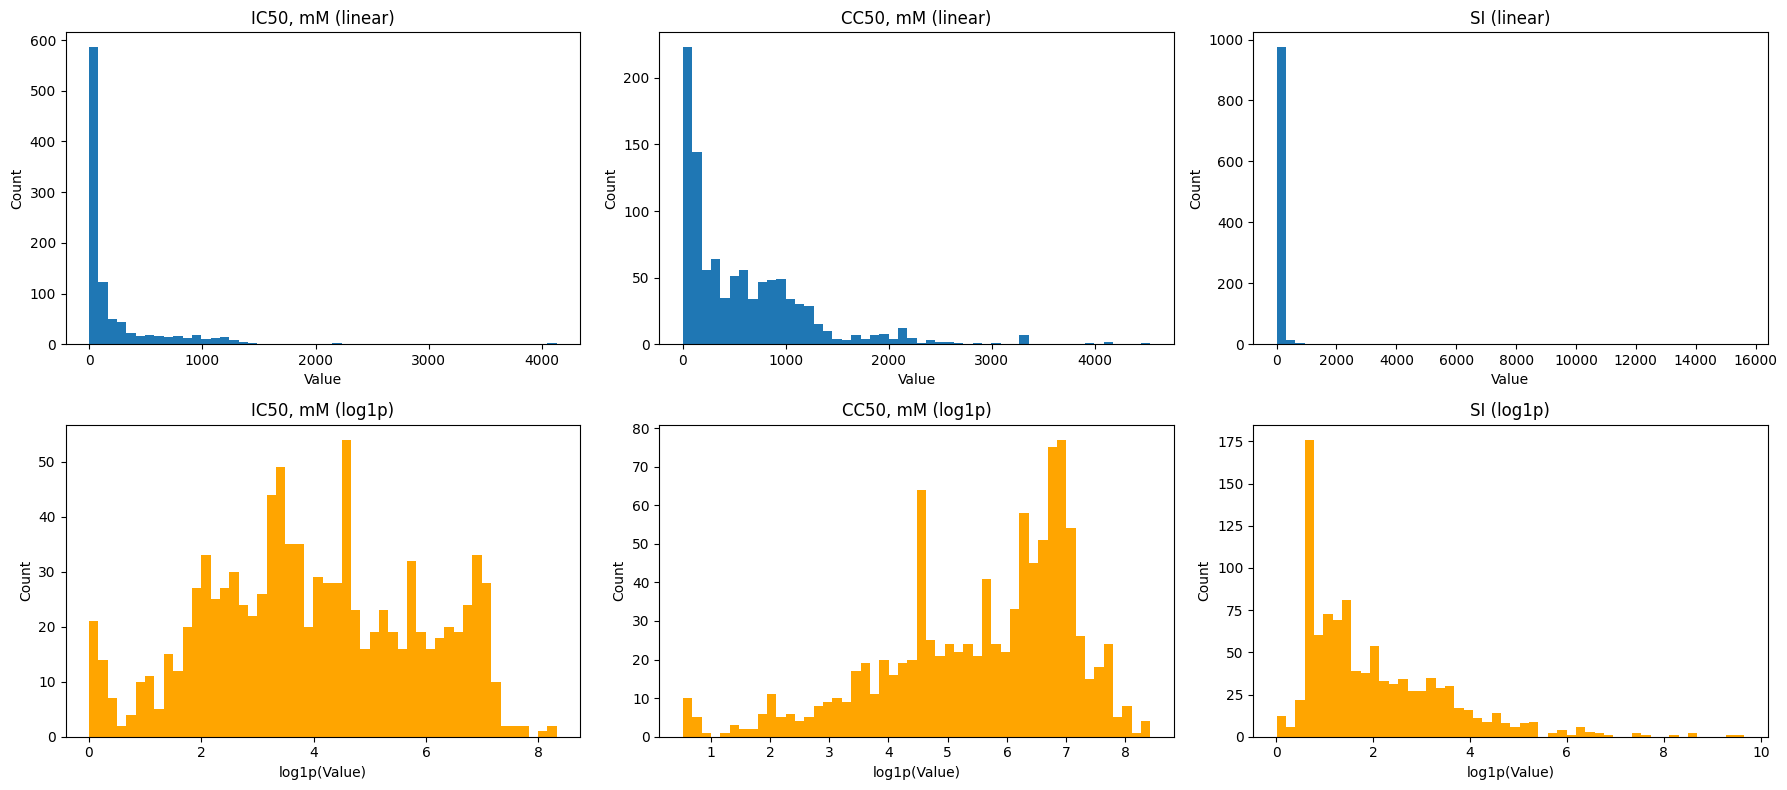


Statistics for log-transformed targets:

IC50, mM:
  Original - mean: 222.81, std: 402.17, skew: 3.67
  Log1p    - mean: 3.98, std: 1.86, skew: -0.03

CC50, mM:
  Original - mean: 589.11, std: 642.87, skew: 1.97
  Log1p    - mean: 5.57, std: 1.59, skew: -0.91

SI:
  Original - mean: 72.51, std: 684.48, skew: 18.01
  Log1p    - mean: 2.04, std: 1.46, skew: 1.43
Shape after removing duplicates: (969, 216)

Final shape: (969, 216)
Remaining missing values: 0
Features before variance filter: 210
Features after variance filter (threshold=0.01): 176
Removed 34 low-variance features
Highly correlated features (threshold=0.95) to drop: 33
First 10: ['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MinAbsPartialCharge', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n']
Features after correlation filter: 143
Top 10 features by correlation with each target:
                IC50_log  CC50_log    SI_log
AvgIpc          0.073344  0.018200  0.134782
BCUT2D_CHGHI    0.022653  0.0582

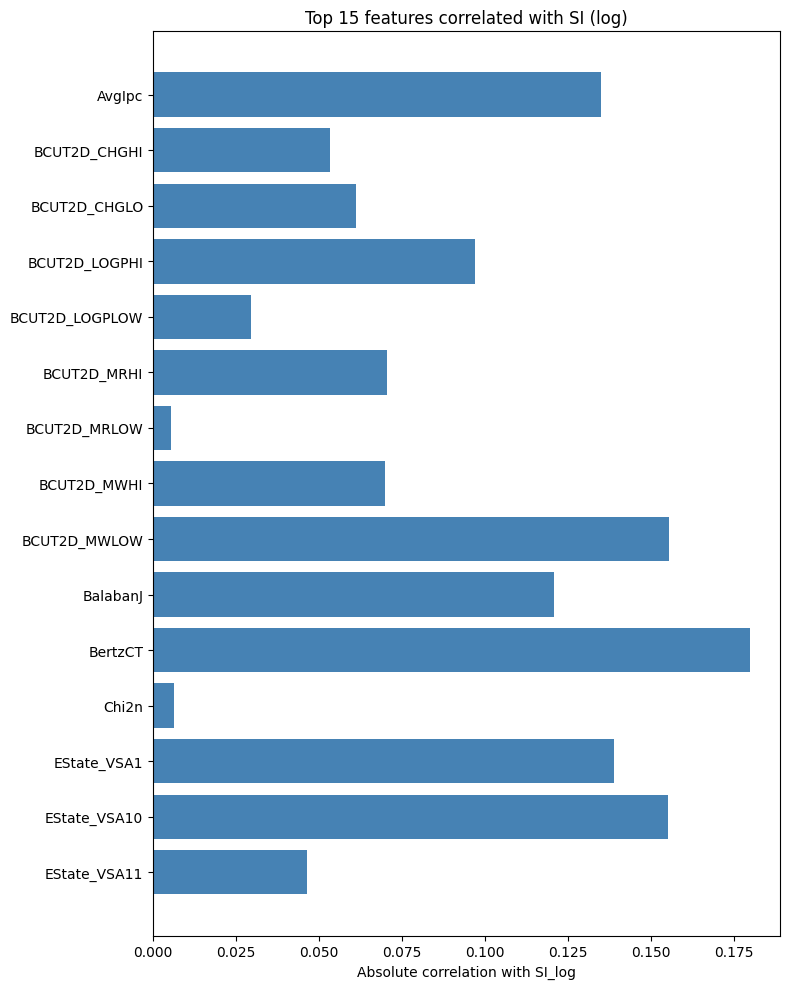

In [2]:
import ipynb.fs.full.eda as eda

df = eda.df
X_filtered = eda.X_filtered

# Обучение

## Выбор базовой модели

Сравним линейную (`Ridge` для регрессии и `LogisticRegression` для классификации), `RandomForset` и `CatBoost`

In [3]:
RegressionModel = Ridge | RandomForestRegressor | CatBoostRegressor
ClassificationModel = LogisticRegression | RandomForestClassifier | CatBoostClassifier

def CompareRegressors(X_train: DataFrame, y_train: ndarray, X_test: DataFrame, y_test: ndarray) -> tuple[RegressionModel, dict[str, dict[str, float]]]:
    models: dict[str, RegressionModel] = {
        "Ridge": Ridge(random_state = 42),
        "RandomForest": RandomForestRegressor(n_estimators = 100, random_state = 42, n_jobs = -1),
        "CatBoost": CatBoostRegressor(random_state = 42, verbose = 0, iterations = 200)
    }

    best_model: Optional[RegressionModel] = None
    best_score = float("inf")
    results: dict[str, float] = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred: ndarray = model.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results[name] = {"rmse": rmse, "r2": r2}
        if rmse < best_score:
            best_score = rmse
            best_model = model

    return best_model, results

def CompareClassifiers(X_train: DataFrame, y_train: ndarray, X_test: DataFrame, y_test: ndarray) -> tuple[ClassificationModel, dict[str, dict[str, float]]]:
    models: dict[str, ClassificationModel] = {
        "LogisticRegression": LogisticRegression(random_state = 42, max_iter = 1000),
        "RandomForest": RandomForestClassifier(n_estimators = 100, random_state = 42, n_jobs = -1),
        "CatBoost": CatBoostClassifier(random_state = 42, verbose = 0, iterations = 200)
    }

    best_model: Optional[RegressionModel] = None
    best_score = 0.0
    results: dict[str, float] = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred: ndarray = model.predict(X_test)
        y_proba: ndarray = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        results[name] = {
            "roc_auc": roc_auc,
            "accuracy": accuracy,
            "f1": f1
        }
        if roc_auc > best_score:
            best_score = roc_auc
            best_model = model

    return best_model, results

In [4]:
best_models: dict[str, Optional[ClassificationModel | RegressionModel]] = {}

regression_results_list: list[dict] = []
classification_results_list: list[dict] = []

regression_tasks: list[tuple[str, str]] = [
    ("IC50 Regression", "IC50, mM"),
    ("CC50 Regression", "CC50, mM"),
    ("SI Regression", "SI")
]

classification_tasks: list[tuple[str, str, Optional[float]]] = [
    ("IC50 > Median", "IC50, mM", None),
    ("CC50 > Median", "CC50, mM", None),
    ("SI > Median", "SI", None),
    ("SI > 8", "SI", 8.0)
]

for task_name, col in regression_tasks:
    y_raw: ndarray = df[col].values
    y_reg: ndarray = np.log1p(y_raw)

    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_reg, test_size = 0.2, random_state = 42)

    best_model, metrics = CompareRegressors(X_train, y_train, X_test, y_test)
    best_models[task_name] = best_model

    for model_name, values in metrics.items():
        regression_results_list.append({
            "Task": task_name,
            "Model": model_name,
            "RMSE": values["rmse"],
            "R2": values["r2"]
        })

    best_rmse = min(metrics.values(), key = lambda x: x["rmse"])
    best_model_name = [name for name, values in metrics.items() if values["rmse"] == best_rmse["rmse"]][0]
    print(f"{task_name}: Best model = {best_model_name} (RMSE: {best_rmse['rmse']:.4f}, R2: {best_rmse['r2']:.4f})")



for task_name, col, threshold in classification_tasks:
    y_raw: ndarray = df[col].values
    if threshold is None:
        threshold = np.median(y_raw)

    y_cls: ndarray = (y_raw > threshold).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_cls, test_size = 0.2, random_state = 42, stratify = y_cls)

    best_model, metrics = CompareClassifiers(X_train, y_train, X_test, y_test)
    best_models[task_name] = best_model

    for model_name, values in metrics.items():
        classification_results_list.append({
            "Task": task_name,
            "Model": model_name,
            "ROC-AUC": values["roc_auc"],
            "Accuracy": values["accuracy"],
            "F1": values["f1"]
        })

    best_auc = max(metrics.values(), key = lambda x: x["roc_auc"])
    best_model_name = [name for name, values in metrics.items() if values["roc_auc"] == best_auc["roc_auc"]][0]
    print(f"{task_name}: Best model = {best_model_name} (ROC-AUC: {best_auc['roc_auc']:.4f}, Accuracy: {best_auc['accuracy']:.4f}, F1: {best_auc['f1']:.4f})")

regression_df: DataFrame = DataFrame(regression_results_list)
classification_df: DataFrame = DataFrame(classification_results_list)

print("\nRegression results:", regression_df.to_string(index = False))
print("\nClassification results:", classification_df.to_string(index = False))

IC50 Regression: Best model = RandomForest (RMSE: 1.4334, R2: 0.4431)
CC50 Regression: Best model = RandomForest (RMSE: 1.2906, R2: 0.2910)
SI Regression: Best model = RandomForest (RMSE: 1.3717, R2: 0.1672)
IC50 > Median: Best model = CatBoost (ROC-AUC: 0.8055, Accuracy: 0.7216, F1: 0.7273)
CC50 > Median: Best model = RandomForest (ROC-AUC: 0.8445, Accuracy: 0.7526, F1: 0.7474)
SI > Median: Best model = CatBoost (ROC-AUC: 0.6939, Accuracy: 0.6598, F1: 0.6374)
SI > 8: Best model = CatBoost (ROC-AUC: 0.7557, Accuracy: 0.7371, F1: 0.5785)

Regression results:            Task        Model     RMSE        R2
IC50 Regression        Ridge 1.587528  0.316937
IC50 Regression RandomForest 1.433411  0.443123
IC50 Regression     CatBoost 1.439453  0.438418
CC50 Regression        Ridge 1.334436  0.241973
CC50 Regression RandomForest 1.290553  0.291009
CC50 Regression     CatBoost 1.308867  0.270744
  SI Regression        Ridge 1.503248 -0.000150
  SI Regression RandomForest 1.371711  0.167222
  SI

Везде видим довольно стандартную историю:

- Регрессия
    - Линейная модель обучается хуже, данные явно сильно нелинейны для `SI` и `IC50`, это хорошо согласуется с EDA
    - `CatBoost` и `RandomForest` показывают очень близкие метрики.

    - `RandomForest` обычно чуть больше переобучается, `CatBoost` должен бы быть стабильнее на маленьких `lr` + тоньше настройка через гиперпараметры.

- Классификация
    - `CatBoost` показывает результат получше по `ROC-AUC`, незначитаельно проигрывая `RandomForest` только для `CC50 > Median`
    - Линейная модель так же явно проигрывает, показывая `ROC-AUC` близкий к $\sim \frac{1}{2}$

Я продолжу дальше через `Optuna` с `CatBoost`'ом

## Подбор гиперпараметров

Запускаем побор через `optuna`:

In [5]:
def TrainRegressionTarget(X_train: DataFrame, y_train: ndarray, X_test: DataFrame, y_test: ndarray, target_name: str) -> tuple[CatBoostRegressor, dict]:
    def Objective(trial: optuna.Trial) -> float:
        params: dict = {
            "iterations": trial.suggest_int("iterations", 200, 1000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log = True),
            "depth": trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
            "random_strength": trial.suggest_float("random_strength", 0.1, 10),
            "verbose": 0,
            "random_state": 42
        }
        model: CatBoostRegressor = CatBoostRegressor(**params)
        cv_scores: ndarray = -cross_val_score(model, X_train, y_train, cv = KFold(n_splits = 5, shuffle = True, random_state = 42), scoring = "neg_root_mean_squared_error")
        return cv_scores.mean()
    
    study: optuna.Study = optuna.create_study(direction = "minimize")
    study.optimize(Objective, n_trials = 25, show_progress_bar = True)
    
    best_model: CatBoostRegressor = CatBoostRegressor(**study.best_params, random_state = 42, verbose = 0)
    best_model.fit(X_train, y_train)
    
    y_pred: ndarray = best_model.predict(X_test)
    metrics: dict = {
        "rmse": root_mean_squared_error(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
        "best_params": study.best_params
    }
    
    print(f"{target_name} regression - Test RMSE: {metrics['rmse']:.4f}, R2: {metrics['r2']:.4f}")
    return best_model, metrics

def TrainClassificationTarget(X_train: DataFrame, y_train: ndarray, X_test: DataFrame, y_test: ndarray, target_name: str, threshold: float) -> tuple[CatBoostClassifier, dict]:
    def Objective(trial: optuna.Trial) -> float:
        params: dict = {
            "iterations": trial.suggest_int("iterations", 200, 1000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log = True),
            "depth": trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
            "verbose": 0,
            "random_state": 42
        }
        model: CatBoostClassifier = CatBoostClassifier(**params)
        cv_scores: ndarray = cross_val_score(model, X_train, y_train, cv = KFold(n_splits = 5, shuffle = True, random_state = 42), scoring = "roc_auc")
        return cv_scores.mean()
    
    study: optuna.Study = optuna.create_study(direction = "maximize")
    study.optimize(Objective, n_trials = 25, show_progress_bar = True)
    
    best_model: CatBoostClassifier = CatBoostClassifier(**study.best_params, random_state = 42, verbose = 0)
    best_model.fit(X_train, y_train)
    
    y_pred_proba: ndarray = best_model.predict_proba(X_test)[:, 1]
    y_pred: ndarray = best_model.predict(X_test)
    
    metrics: dict = {
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
        "accuracy": (y_pred == y_test).mean(),
        "f1": f1_score(y_test, y_pred),
        "best_params": study.best_params
    }
    
    print(f"{target_name} classification (threshold={threshold}) - Test ROC-AUC: {metrics['roc_auc']:.4f}, Accuracy: {metrics['accuracy']:.4f}")
    return best_model, metrics

In [ ]:
regression_results: dict = {}
regression_models: dict = {}

target_cols: list[str] = ["IC50, mM", "CC50, mM", "SI"]

for col in target_cols:
    y_raw: ndarray = df[col].values
    y_reg: ndarray = np.log1p(y_raw)
    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_reg, test_size = 0.2, random_state = 42)
    model, metrics = TrainRegressionTarget(X_train, y_train, X_test, y_test, col)
    regression_results[col] = metrics
    regression_models[col] = model

print("Regression Summary")
for target, metrics in regression_results.items():
    print(f"{target}: RMSE={metrics['rmse']:.4f}, R2={metrics['r2']:.4f}")


classification_results: dict = {}
classification_models: dict = {}

classification_configs: list[tuple[str, str, Optional[float]]] = [
    ("IC50, mM", "IC50_median", None),
    ("CC50, mM", "CC50_median", None),
    ("SI", "SI_median", None),
    ("SI", "SI_8", 8.0)
]

for col, task_name, threshold in classification_configs:
    y_raw: ndarray = df[col].values
    if threshold is None:
        threshold = np.median(y_raw)
    y_cls: ndarray = (y_raw > threshold).astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered, y_cls, test_size = 0.2, random_state = 42, stratify = y_cls
    )
    
    model, metrics = TrainClassificationTarget(X_train, y_train, X_test, y_test, task_name, threshold)
    classification_results[task_name] = metrics
    classification_models[task_name] = model

print("\nClassification Summary")
for task, metrics in classification_results.items():
    print(f"{task}: ROC-AUC={metrics['roc_auc']:.4f}, Accuracy={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}")

  0%|          | 0/25 [00:00<?, ?it/s]

IC50, mM regression - Test RMSE: 1.3502, R2: 0.5059


  0%|          | 0/25 [00:00<?, ?it/s]

CC50, mM regression - Test RMSE: 1.2376, R2: 0.3480


  0%|          | 0/25 [00:00<?, ?it/s]

...

CC50_median classification (threshold=424.1662130966011) - Test ROC-AUC: 0.8363, Accuracy: 0.7268


  0%|          | 0/25 [00:00<?, ?it/s]

SI_median classification (threshold=3.899999999999999) - Test ROC-AUC: 0.7011, Accuracy: 0.6443


  0%|          | 0/25 [00:00<?, ?it/s]

SI_8 classification (threshold=8.0) - Test ROC-AUC: 0.7475, Accuracy: 0.7474

Classification Summary
IC50_median: ROC-AUC=0.8172, Accuracy=0.7423, F1=0.7475
CC50_median: ROC-AUC=0.8363, Accuracy=0.7268, F1=0.7254
SI_median: ROC-AUC=0.7011, Accuracy=0.6443, F1=0.6102
SI_8: ROC-AUC=0.7475, Accuracy=0.7474, F1=0.5739


Сравнение метрик:

|         | RMSE   | R2     |
|---------|--------|--------|
| IC50 (old) | 1.4334 | 0.4431 |
| IC50 (new) | 1.3502 | 0.5059 |
| CC50 (old) | 1.2906 | 0.2910 |
| CC50 (new) | 1.2376 | 0.3480 |
| SI (old)   | 1.3717 | 0.1672 |
| SI (new)   | 1.3202 | 0.2286 |

$ $

|                   | ROC-AUC | Accuracy | F1     |
|-------------------|---------|----------|--------|
| IC50_median (old) | 0.8055  | 0.7216   | 0.7273 |
| IC50_median (new) | 0.8172  | 0.7423   | 0.7475 |
| CC50_median (old) | 0.8445  | 0.7526   | 0.7474 |
| CC50_median (new) | 0.8363  | 0.7268   | 0.7254 |
| SI_median (old)   | 0.6939  | 0.6598   | 0.6374 |
| SI_median (new)   | 0.7011  | 0.6443   | 0.6102 |
| SI_8 (old)        | 0.7557  | 0.7371   | 0.5785 |
| SI_8 (new)        | 0.7475  | 0.7474   | 0.5739 |

- регрессии:
    - везде ощутимый прирост по сравнению с резульатом до подбора.
    - на $5-6\%$ (абсолютно) вырос $R^2$, это очень значимый прирост
    - сопровождается паданием и `RMSE`
    - выбор `CatBoost` + подбор параметров довольно хорошо себя показал и обогнал случайные леса

- классификации
    - чуть менее явные разницы
    - заметный прирост по `ROC-AUC` для `IC50`($+1.2 \%$) вместе с возросшей точностью и `F1`
    - метрики почти не поменялись для `SI (median)` (`ROC-AUC` слегка выросла, но упали точность и `F1`) и `SI (8)` (обратная ситуация, чуть растёт точность, но падают `ROC-AUC` c `F1`)
    - для `CC50` метрики *сильно* хуже, в этом месте катбуст так и не догнал случайный лес. Лучшей моделью остается `RandomForest`
    - для тех остальных, либо маловато итераций для `optuna`, либо довольно удачно попадет дефолтная настройка. Возможно качество можно поднять, расширив интервалы параметров и увеличив число итераций

## Визуализация

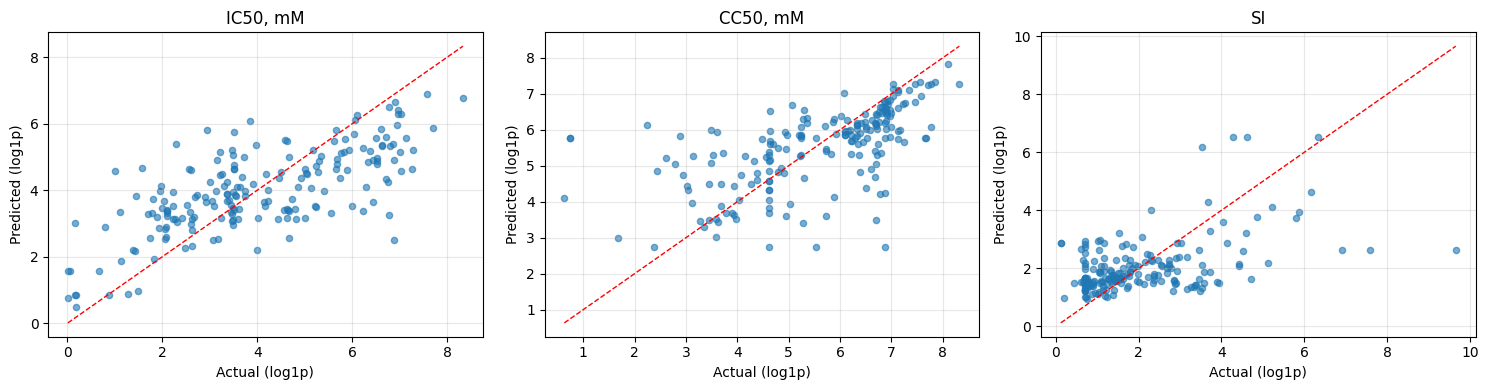

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

for idx, target in enumerate(["IC50, mM", "CC50, mM", "SI"]):
    model = regression_models[target]
    
    y_raw: ndarray = df[target].values
    y_reg: ndarray = np.log1p(y_raw)
    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_reg, test_size = 0.2, random_state = 42)
    
    y_pred: ndarray = model.predict(X_test)
    
    axes[idx].scatter(y_test, y_pred, alpha = 0.6, s = 20)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw = 1)
    axes[idx].set_xlabel("Actual (log1p)")
    axes[idx].set_ylabel("Predicted (log1p)")
    axes[idx].set_title(f"{target}")
    axes[idx].grid(alpha = 0.3)

plt.tight_layout()
plt.savefig("graphs/1_regression_predicted_vs_actual.png", dpi = 150)
plt.show()

- точки распределены вокруг диагонали с заметным разбросом (особенно для низких значений `SI`)
- возможно играет наша логарифмическая шкала, опять, это место в EDA, где потенциально можно улучшить качество моделей
- общий тренд модель довольно хорошо ловит, но умеет довольно сильно ошибаться в таргете

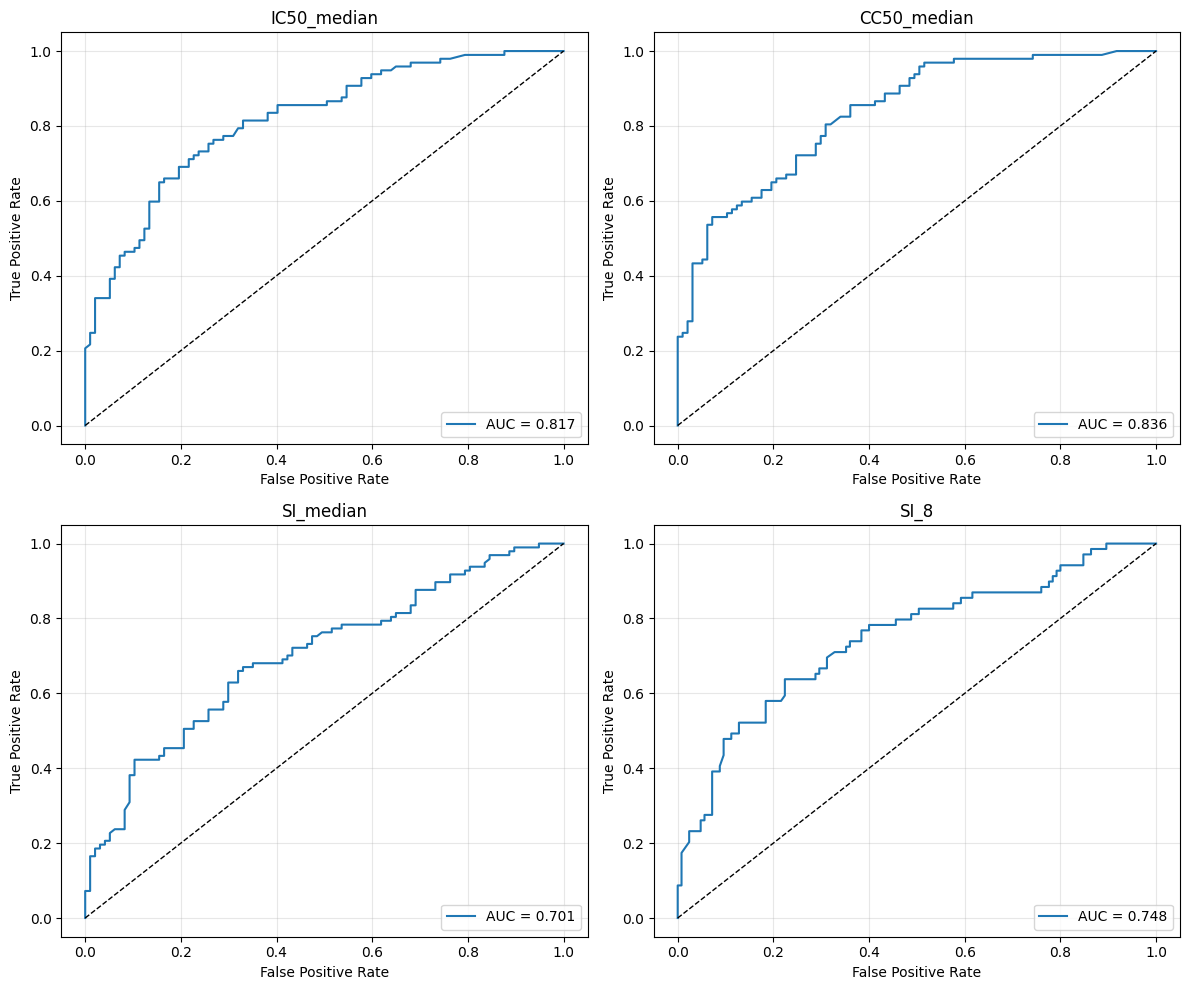

In [ ]:
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
axes = axes.flatten()

cls_configs: list[tuple[str, str, float]] = [
    ("IC50_median", "IC50, mM", -1.0),
    ("CC50_median", "CC50, mM", -1.0),
    ("SI_median", "SI", -1.0),
    ("SI_8", "SI", 8.0)
]

for idx, (task_name, col, thr) in enumerate(cls_configs):
    model = classification_models[task_name]
    y_raw: ndarray = df[col].values
    threshold: float = np.median(y_raw) if thr == -1.0 else thr
    y_cls: ndarray = (y_raw > threshold).astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_cls, test_size = 0.2, random_state = 42, stratify = y_cls)
    
    y_proba: ndarray = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val: float = roc_auc_score(y_test, y_proba)
    
    axes[idx].plot(fpr, tpr, label = f"AUC = {auc_val:.3f}")
    axes[idx].plot([0, 1], [0, 1], "k--", lw = 1)
    axes[idx].set_xlabel("False Positive Rate")
    axes[idx].set_ylabel("True Positive Rate")
    axes[idx].set_title(f"{task_name}")
    axes[idx].legend(loc = "lower right")
    axes[idx].grid(alpha = 0.3)

plt.tight_layout()
plt.savefig("graphs/2_classification_roc_curves.png", dpi = 150)
plt.show()


- для `IC50` и `CC50` `ROC`-кривые находятся сильно выше (`AUC > 0.8`) случайного угадывания, показывает эффективность моделей
- для обоих предсказаний `SI` качество значимо ниже, но модель всё равно эффективна

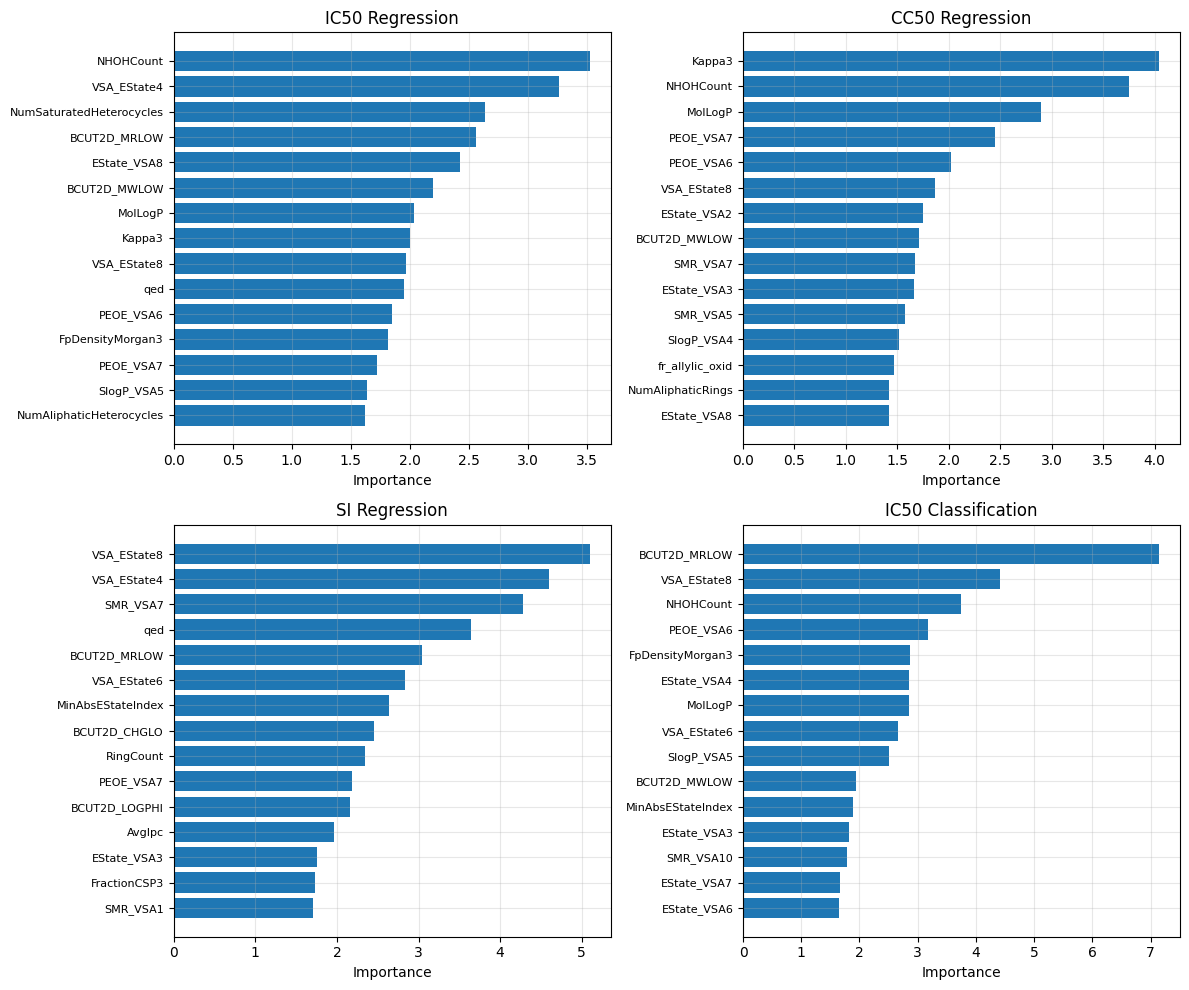

In [ ]:
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
axes = axes.flatten()

models_to_plot: list[tuple[str, RegressionModel | ClassificationModel]] = [
    ("IC50 Regression", regression_models["IC50, mM"]),
    ("CC50 Regression", regression_models["CC50, mM"]),
    ("SI Regression", regression_models["SI"]),
    ("IC50 Classification", classification_models["IC50_median"])
]

for idx, (title, model) in enumerate(models_to_plot):
    importances: ndarray = model.feature_importances_
    indices: ndarray = np.argsort(importances)[-15:]
    
    axes[idx].barh(range(15), importances[indices])
    axes[idx].set_yticks(range(15))
    axes[idx].set_yticklabels([X_filtered.columns[i] for i in indices], fontsize = 8)
    axes[idx].set_xlabel("Importance")
    axes[idx].set_title(title)
    axes[idx].grid(alpha = 0.3)

plt.tight_layout()
plt.savefig("graphs/3_feature_importance.png", dpi = 150)
plt.show()

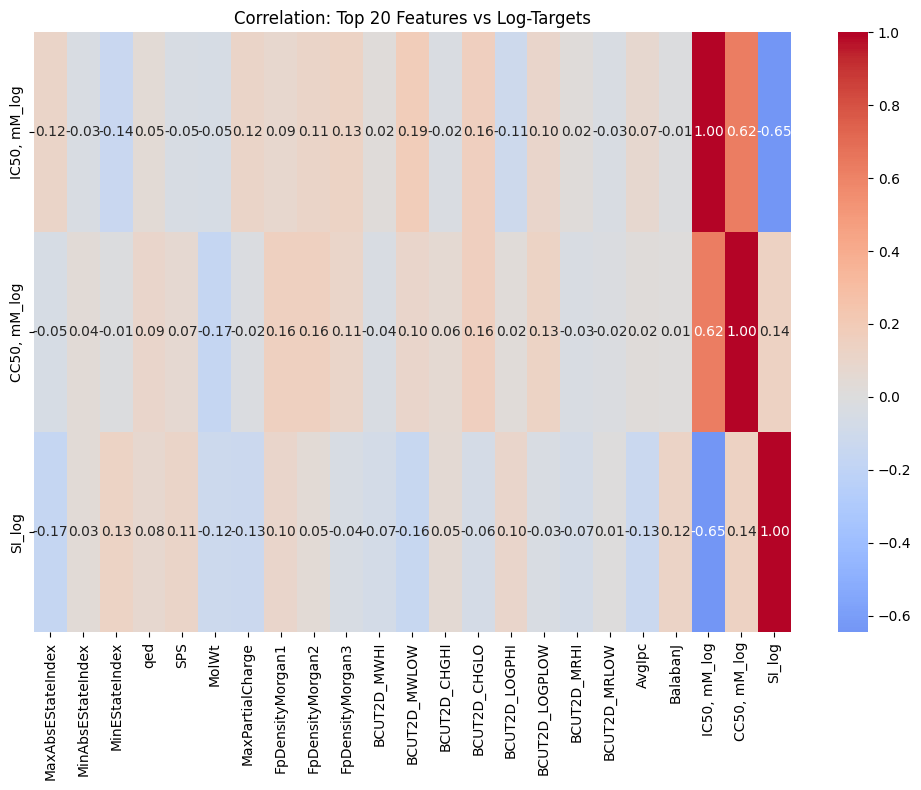

In [87]:
sample_features: list[str] = list(X_filtered.columns[:20])
target_cols_log: list[str] = ["IC50, mM_log", "CC50, mM_log", "SI_log"]

temp_df: DataFrame = X_filtered[sample_features].copy()
for tc in target_cols_log:
    if tc in df.columns:
        temp_df[tc] = df[tc]
    else:
        temp_df[tc] = np.log1p(df[tc.replace("_log", "")])

corr_matrix: DataFrame = temp_df.corr()
del temp_df

plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix[target_cols_log].T, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0)
plt.title("Correlation: Top 20 Features vs Log-Targets")
plt.tight_layout()
plt.savefig("graphs/4_correlations.png", dpi = 150)
plt.show()

# Выводы

- EDA подтвердил нелинейный характер зависимостей и необходимость нормализации таргетов
- `CatBoost` с подбором гиперпараметров показывает лучшие результаты:
    - регрессии: `IC50 R²=0.51`, `CC50 R²=0.35`, `SI R²=0.23`
    - классификации `IC50 > медиана AUC=0.82`, `CC50 > медиана AUC=0.84`, `SI > медиана AUC=0.7`, `SI > 8 AUC=0.75`

    - но для `CC50 > медиана` `CatBoost` так и не догнал `RandomForest`, у которого чуть выше `AUC=0.85`

### Рекомендации по улучшению:

- Данные: увеличение выборки, добавление простанственных (или графовых?) признаков
- EDA: подбор более удачного преобразования таргетов `CC50` и `SI`, конструирование производных признаков
- Модели: попробовать ансамбли
- Внедрить `GroupKFold` для валидации: проверить обобщаующю способность на новые группы химических соединений